In [1]:
import dynamax
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt

In [4]:
with open("../../gdrive/models/models/condition_lds_poisson_cond1_bin50_state8_steps100_seed7.pkl", 'rb') as f:
    model = pkl.load(f)

In [11]:
A = model['fit']['trainable_params']['A']

In [14]:
svd = np.linalg.svd(A)

In [ ]:
bins = 50

for (dist, stp) in zip(['gaussian', 'poisson'], ['iters', 'steps']):
# dist = 'poisson'
# stp = 'steps'
    for cond in range(1,9):
        for state in [8, 12, 18]:
            file = f"../../gdrive/models/models/condition_lds_{dist}_cond{cond}_bin{bins}_state{state}_{stp}100_seed7.pkl"
            
            with open(file, 'rb') as f:
                if dist == 'poisson':
                    # continue
                    model_params = pkl.load(f)['fit']['trainable_params']
                    A = model_params['A']
                else:
                    model_params = pkl.load(f)['fit']['params']
                    A = model_params.dynamics.weights
                    # b = model_params.dynamics.bias
                
    

In [41]:
es = np.linalg.eig(A).eigenvalues
es

array([0.7340996 +0.53560513j, 0.7340996 -0.53560513j,
       0.8759354 +0.26590212j, 0.8759354 -0.26590212j,
       0.95375811+0.17174642j, 0.95375811-0.17174642j,
       0.9454734 +0.12150761j, 0.9454734 -0.12150761j,
       0.95421195+0.04200691j, 0.95421195-0.04200691j,
       0.99572122+0.05241871j, 0.99572122-0.05241871j,
       0.97608979+0.00166015j, 0.97608979-0.00166015j,
       1.00786048+0.j        , 1.00125029+0.j        ,
       0.99126469+0.j        , 0.99507358+0.j        ])

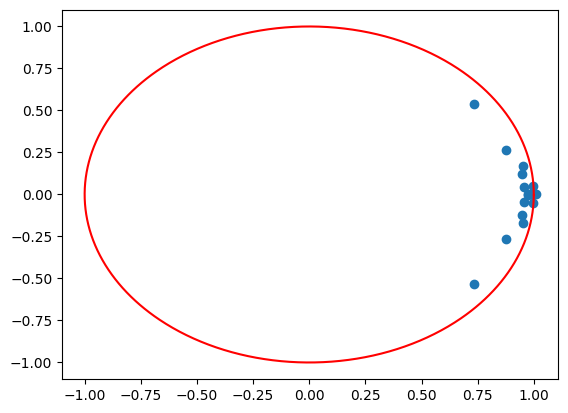

In [47]:
plt.scatter(np.real(es), np.imag(es))
plt.plot(np.cos(np.arange(1000) / 1000 * 2 * np.pi), np.sin(np.arange(1000) / 1000 * 2 * np.pi), color='red')

In [31]:
model_params.keys()

dict_keys(['A', 'C', 'd', 'log_q', 'm0', 'log_s0'])

In [38]:
with open("../../gdrive/models/models/condition_lds_gaussian_cond1_bin50_state8_iters100_seed7.pkl", 'rb') as f:
    model_params = pkl.load(f)['fit']

In [39]:
model_params['params'].dynamics.weights


Array([[ 9.4218534e-01,  1.1759762e-02,  1.8694840e-02, -1.3255947e-02,
         7.2173770e-03, -1.3148753e-02,  1.1774809e-02, -6.3917309e-02],
       [ 7.5223437e-03,  9.3697447e-01,  2.8447773e-02, -1.9403718e-02,
         1.7059460e-02, -7.7246726e-03, -9.2180893e-03, -2.1667739e-02],
       [-4.0887478e-03,  7.7396492e-03,  9.2176837e-01,  2.9129611e-02,
        -1.0432284e-02, -4.9079191e-03, -2.9051900e-02,  2.7964571e-02],
       [-4.4404319e-03, -1.8150376e-02, -3.0164677e-04,  9.2554134e-01,
        -1.0414347e-02,  2.0672459e-02, -3.0001612e-02,  1.8304965e-02],
       [-3.4587046e-03, -4.6674879e-03, -5.2860631e-03,  4.1578230e-02,
         9.4703609e-01, -2.0129502e-02, -4.3476028e-03,  1.9736001e-03],
       [ 3.7457899e-03,  2.1361308e-02,  2.3045801e-02, -1.1208190e-02,
        -5.2299216e-02,  9.1876024e-01,  2.1859540e-03, -2.9175522e-02],
       [-1.0980579e-02, -1.0546929e-02, -1.2775034e-02,  3.0777985e-03,
        -4.6367460e-04, -2.3380093e-02,  9.4450772e-01, -9